**Common Valid Days Across All LSA from 16 to 1**

In [2]:
from pathlib import Path
import json
import re
import pandas as pd

# ============================================================
# SETTINGS
# ============================================================
BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell"
)

OUT_DIR = BASE_DIR / "aktuell_detectors_output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

INTERSECTIONS = [
    "LD-LSA1",
    #"LD-LSA8",
    "LD-LSA9",
    "LD-LSA10",
    "LD-LSA16",
]

DATE_PATTERN = re.compile(r"^\d{4}-\d{2}-\d{2}\.json$")

# ============================================================
# VALIDITY CHECK
# ============================================================
def is_valid_json_day(file_path: Path) -> bool:
    try:
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        timeframes = data.get("timeFrames", None)

        # must exist and be a non-empty list
        if not isinstance(timeframes, list) or len(timeframes) == 0:
            return False

        # at least one detector count must be > 0
        for tf in timeframes:
            detectors = tf.get("detectors", [])
            if not isinstance(detectors, list):
                continue

            for det in detectors:
                count = det.get("reading", {}).get("count", {}).get("value", 0)

                try:
                    if float(count) > 0:
                        return True
                except (TypeError, ValueError):
                    continue

        return False

    except Exception as e:
        print(f"[ERROR] Could not read {file_path}: {e}")
        return False

# ============================================================
# COLLECT VALID DAYS PER INTERSECTION
# ============================================================
valid_days = {}

for intersection in INTERSECTIONS:
    folder = BASE_DIR / intersection

    if not folder.exists():
        print(f"[WARNING] Folder not found: {folder}")
        valid_days[intersection] = set()
        continue

    dates = set()

    for file in folder.iterdir():
        if file.is_file() and DATE_PATTERN.match(file.name):
            if is_valid_json_day(file):
                dates.add(file.stem)

    valid_days[intersection] = dates

    sorted_dates = sorted(dates)
    first_day = sorted_dates[0] if sorted_dates else None
    last_day = sorted_dates[-1] if sorted_dates else None

    print(f"{intersection} valid days: {len(dates)}")
    print(f"  first_valid_day: {first_day}")
    print(f"  last_valid_day : {last_day}")

# ============================================================
# COMMON VALID DAYS ACROSS ALL INTERSECTIONS
# ============================================================
if valid_days and all(len(valid_days[i]) > 0 for i in INTERSECTIONS):
    common_days = sorted(set.intersection(*(valid_days[i] for i in INTERSECTIONS)))
else:
    common_days = []

print("\n============================================================")
print(f"COMMON VALID DAYS ACROSS ALL INTERSECTIONS: {len(common_days)}")
print("============================================================")

for d in common_days:
    print(d)

# ============================================================
# SAVE RESULTS
# ============================================================
# 1) summary
summary_rows = []
for intersection, days in valid_days.items():
    sorted_days = sorted(days)
    summary_rows.append({
        "intersection": intersection,
        "valid_day_count": len(days),
        "first_valid_day": sorted_days[0] if sorted_days else None,
        "last_valid_day": sorted_days[-1] if sorted_days else None
    })

df_summary = pd.DataFrame(summary_rows)
summary_file = OUT_DIR / "valid_day_summary.csv"
df_summary.to_csv(summary_file, index=False, encoding="utf-8-sig")

# 2) common days across all intersections
df_common = pd.DataFrame({"date": common_days})
if not df_common.empty:
    df_common["date"] = pd.to_datetime(df_common["date"])
    df_common["day_name"] = df_common["date"].dt.day_name()
    df_common["weekday_num"] = df_common["date"].dt.weekday
    df_common["month"] = df_common["date"].dt.month
    df_common["is_weekend"] = df_common["weekday_num"] >= 5

common_file = OUT_DIR / "common_valid_days_all_intersections.csv"
df_common.to_csv(common_file, index=False, encoding="utf-8-sig")

# 3) presence matrix
all_days = sorted(set.union(*(days for days in valid_days.values()))) if valid_days else []

presence_rows = []
for day in all_days:
    row = {"date": day}
    for intersection in INTERSECTIONS:
        row[intersection] = day in valid_days[intersection]
    presence_rows.append(row)

df_presence = pd.DataFrame(presence_rows)
if not df_presence.empty:
    df_presence["date"] = pd.to_datetime(df_presence["date"])
    df_presence = df_presence.sort_values("date")

presence_file = OUT_DIR / "valid_day_presence_matrix.csv"
df_presence.to_csv(presence_file, index=False, encoding="utf-8-sig")

print("\nSaved files:")
print(summary_file)
print(common_file)
print(presence_file)

LD-LSA1 valid days: 29
  first_valid_day: 2026-03-01
  last_valid_day : 2026-03-30
LD-LSA9 valid days: 32
  first_valid_day: 2026-03-01
  last_valid_day : 2026-04-01
LD-LSA10 valid days: 32
  first_valid_day: 2026-03-01
  last_valid_day : 2026-04-01
LD-LSA16 valid days: 28
  first_valid_day: 2026-03-05
  last_valid_day : 2026-04-01

COMMON VALID DAYS ACROSS ALL INTERSECTIONS: 25
2026-03-05
2026-03-06
2026-03-07
2026-03-08
2026-03-09
2026-03-10
2026-03-11
2026-03-12
2026-03-13
2026-03-14
2026-03-16
2026-03-17
2026-03-18
2026-03-19
2026-03-20
2026-03-21
2026-03-22
2026-03-23
2026-03-24
2026-03-25
2026-03-26
2026-03-27
2026-03-28
2026-03-29
2026-03-30

Saved files:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\aktuell_detectors_output\valid_day_summary.csv
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\aktuell_detectors_output\common_valid_days_all_intersections.csv
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\aktuell_detectors_output\val

*Before selecting representative days, the detector data for the intersections LD-LSA16, LD-LSA10, and LD-LSA1 had to be restructured into a consistent long-format dataset for the common valid-day period. The previously available September-based files were not used, since the representative-day analysis was based exclusively on the common valid days identified between 2025-05-26 and 2025-06-24. Therefore, the raw detector data were reprocessed and filtered to this common period before the clustering analysis was carried out.*

**Building Long-Format CSV from Jsons for Common days (LSA16-LSA10-LSA9-LSA1)**

In [1]:
from pathlib import Path
import json
import re
import pandas as pd

# ============================================================
# SETTINGS
# ============================================================
BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell")
COMMON_DAYS_FILE = BASE_DIR / "aktuell_detectors_output" / "common_valid_days_all_intersections.csv"

OUT_DIR = BASE_DIR / "detector_data_CSV_new"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATE_PATTERN = re.compile(r"^\d{4}-\d{2}-\d{2}\.json$")

# ============================================================
# DETECTOR DEFINITIONS
# ============================================================
DETECTOR_MAP = {
    "LD-LSA10": {
        1:  {"detector_name": "VD11", "sumo_id": "LSA10_W_id1",   "approach": "West"},
        31: {"detector_name": "WD52", "sumo_id": "LSA10_S_id31",  "approach": "South"},
        3:  {"detector_name": "VD41", "sumo_id": "LSA10_E_id3",   "approach": "East"},
        4:  {"detector_name": "VD42", "sumo_id": "LSA10_E_id4",   "approach": "East"},
        29: {"detector_name": "WD32", "sumo_id": "LSA10_NE_id29", "approach": "North-East"},
        2:  {"detector_name": "VD25", "sumo_id": "LSA10_NW_id2",  "approach": "North-West"},
        26: {"detector_name": "WD23", "sumo_id": "LSA10_NW_id26", "approach": "North-West"},
        27: {"detector_name": "WD24", "sumo_id": "LSA10_NW_id27", "approach": "North-West"},
    },

    "LD-LSA16": {
        5:  {"detector_name": "VD23",  "sumo_id": "LSA16_W_id5",     "approach": "West"},
        4:  {"detector_name": "WD22",  "sumo_id": "LSA16_W_id4",     "approach": "West"},
        3:  {"detector_name": "WD21",  "sumo_id": "LSA16_W_id3",     "approach": "West"},
        15: {"detector_name": "D46",   "sumo_id": "LSA16_Wout_id15", "approach": "West-Exit"},
        33: {"detector_name": "VD13",  "sumo_id": "LSA16_S_id33",    "approach": "South"},
        2:  {"detector_name": "VD12",  "sumo_id": "LSA16_S_id2",     "approach": "South"},
        1:  {"detector_name": "VD11",  "sumo_id": "LSA16_S_id1",     "approach": "South"},
        10: {"detector_name": "VD43",  "sumo_id": "LSA16_E_id10",    "approach": "East"},
        11: {"detector_name": "VD4.4", "sumo_id": "LSA16_E_id11",    "approach": "East"},
        13: {"detector_name": "D23",   "sumo_id": "LSA16_Eout_id13", "approach": "East-Exit"},
        7:  {"detector_name": "VD32",  "sumo_id": "LSA16_N_id7",     "approach": "North"},
        6:  {"detector_name": "VD31",  "sumo_id": "LSA16_N_id6",     "approach": "North"},
    },

    "LD-LSA1": {
        8:  {"detector_name": "DET12", "sumo_id": "LSA1_W_id8",  "approach": "West"},
        10: {"detector_name": "DET22", "sumo_id": "LSA1_W_id10", "approach": "West"},
        7:  {"detector_name": "DET11", "sumo_id": "LSA1_W_id7",  "approach": "West"},
        9:  {"detector_name": "DET21", "sumo_id": "LSA1_W_id9",  "approach": "West"},

        12: {"detector_name": "DET32", "sumo_id": "LSA1_S_id12", "approach": "South"},
        11: {"detector_name": "DET31", "sumo_id": "LSA1_S_id11", "approach": "South"},

        14: {"detector_name": "DET42", "sumo_id": "LSA1_E_id14", "approach": "East"},
        24: {"detector_name": "DET44", "sumo_id": "LSA1_E_id24", "approach": "East"},
        26: {"detector_name": "DET52", "sumo_id": "LSA1_E_id26", "approach": "East"},
        27: {"detector_name": "DET61", "sumo_id": "LSA1_E_id27", "approach": "East"},
        13: {"detector_name": "DET41", "sumo_id": "LSA1_E_id13", "approach": "East"},
        23: {"detector_name": "DET43", "sumo_id": "LSA1_E_id23", "approach": "East"},
        25: {"detector_name": "DET51", "sumo_id": "LSA1_E_id25", "approach": "East"},

        29: {"detector_name": "DET72", "sumo_id": "LSA1_N_id29", "approach": "North"},
        39: {"detector_name": "DET74", "sumo_id": "LSA1_N_id39", "approach": "North"},
        40: {"detector_name": "DET81", "sumo_id": "LSA1_N_id40", "approach": "North"},
        28: {"detector_name": "DET71", "sumo_id": "LSA1_N_id28", "approach": "North"},
        30: {"detector_name": "DET73", "sumo_id": "LSA1_N_id30", "approach": "North"},
    },

    "LD-LSA9": {
        2:  {"detector_name": "VD12", "sumo_id": "LSA9_W_id2",  "approach": "West"},
        1:  {"detector_name": "VD11", "sumo_id": "LSA9_W_id1",  "approach": "West"},
        10: {"detector_name": "WD41", "sumo_id": None,          "approach": "South"},
        8:  {"detector_name": "VD31", "sumo_id": "LSA9_E_id8",  "approach": "East"},
        9:  {"detector_name": "VD32", "sumo_id": "LSA9_E_id9",  "approach": "East"},
        6:  {"detector_name": "VD24", "sumo_id": "LSA9_WE_id6", "approach": "North-West"},
        7:  {"detector_name": "VD25", "sumo_id": "LSA9_WE_id7", "approach": "North-West"},
        4:  {"detector_name": "WD22", "sumo_id": "LSA9_WE_id4", "approach": "North-West"},
        5:  {"detector_name": "WD23", "sumo_id": "LSA9_WE_id5", "approach": "North-West"},
        3:  {"detector_name": "WD21", "sumo_id": None,          "approach": "North-East"},
        11: {"detector_name": "VD51", "sumo_id": None,          "approach": "Middle"},
    },
}

# ============================================================
# HELPERS
# ============================================================
def safe_nested_get(d, keys, default=None):
    cur = d
    for k in keys:
        if not isinstance(cur, dict):
            return default
        cur = cur.get(k, default)
    return cur


def load_common_days(common_days_file: Path):
    df = pd.read_csv(common_days_file)
    if "date" not in df.columns:
        raise ValueError(f"'date' column not found in {common_days_file}")
    return set(pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d"))


def extract_rows_from_file(file_path: Path, intersection: str, detector_defs: dict):
    rows = []

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    date_str = file_path.stem
    start_ts = data.get("start")
    end_ts = data.get("end")
    interval_ms = data.get("intervalMilliseconds")
    interval_len = data.get("intervalLength")

    timeframes = data.get("timeFrames", [])
    if not isinstance(timeframes, list):
        return rows

    for tf in timeframes:
        timestamp = tf.get("timestamp")
        detectors = tf.get("detectors", [])
        if not isinstance(detectors, list):
            continue

        for det in detectors:
            det_id = det.get("id")
            if det_id not in detector_defs:
                continue

            meta = detector_defs[det_id]

            row = {
                "date": date_str,
                "timestamp": timestamp,
                "intersection": intersection,
                "detector_id": det_id,
                "detector_name": meta["detector_name"],
                "sumo_id": meta["sumo_id"],
                "approach": meta["approach"],

                "json_start": start_ts,
                "json_end": end_ts,
                "intervalMilliseconds": interval_ms,
                "intervalLength": interval_len,

                "count": safe_nested_get(det, ["reading", "count", "value"]),
                "occupancy": safe_nested_get(det, ["reading", "occupancy", "value"]),
                "speed": safe_nested_get(det, ["reading", "speed", "value"]),

                "count_min": safe_nested_get(det, ["reading", "count", "min"]),
                "count_max": safe_nested_get(det, ["reading", "count", "max"]),
                "count_avg": safe_nested_get(det, ["reading", "count", "average"]),
                "count_std": safe_nested_get(det, ["reading", "count", "stdDeviation"]),

                "occupancy_min": safe_nested_get(det, ["reading", "occupancy", "min"]),
                "occupancy_max": safe_nested_get(det, ["reading", "occupancy", "max"]),
                "occupancy_avg": safe_nested_get(det, ["reading", "occupancy", "average"]),

                "speed_min": safe_nested_get(det, ["reading", "speed", "min"]),
                "speed_max": safe_nested_get(det, ["reading", "speed", "max"]),
                "speed_avg": safe_nested_get(det, ["reading", "speed", "average"]),

                "count_samples_included": safe_nested_get(det, ["reading", "count", "samples", "included"]),
                "count_samples_expected": safe_nested_get(det, ["reading", "count", "samples", "expected"]),
                "count_samples_invalid": safe_nested_get(det, ["reading", "count", "samples", "invalid"]),

                "occupancy_samples_included": safe_nested_get(det, ["reading", "occupancy", "samples", "included"]),
                "occupancy_samples_expected": safe_nested_get(det, ["reading", "occupancy", "samples", "expected"]),
                "occupancy_samples_invalid": safe_nested_get(det, ["reading", "occupancy", "samples", "invalid"]),

                "speed_samples_included": safe_nested_get(det, ["reading", "speed", "samples", "included"]),
                "speed_samples_expected": safe_nested_get(det, ["reading", "speed", "samples", "expected"]),
                "speed_samples_invalid": safe_nested_get(det, ["reading", "speed", "samples", "invalid"]),

                "confidence": det.get("confidence"),
                "idStr": det.get("idStr"),
            }

            rows.append(row)

    return rows


# ============================================================
# MAIN
# ============================================================
common_days = load_common_days(COMMON_DAYS_FILE)

all_rows = []

for intersection, detector_defs in DETECTOR_MAP.items():
    folder = BASE_DIR / intersection

    if not folder.exists():
        print(f"[WARNING] Folder not found: {folder}")
        continue

    intersection_rows = []

    files = sorted([
        p for p in folder.iterdir()
        if p.is_file()
        and DATE_PATTERN.match(p.name)
        and p.stem in common_days
    ])

    print(f"{intersection}: {len(files)} common-day JSON files found")

    for file_path in files:
        try:
            rows = extract_rows_from_file(file_path, intersection, detector_defs)
            intersection_rows.extend(rows)
            all_rows.extend(rows)
        except Exception as e:
            print(f"[ERROR] {intersection} | {file_path.name} -> {e}")

    if intersection_rows:
        df_intersection = pd.DataFrame(intersection_rows)
        df_intersection["date"] = pd.to_datetime(df_intersection["date"])
        df_intersection["timestamp"] = pd.to_datetime(df_intersection["timestamp"], errors="coerce")
        df_intersection = df_intersection.sort_values(
            ["date", "timestamp", "detector_id"]
        ).reset_index(drop=True)

        out_file = OUT_DIR / f"{intersection}_common_days_long.csv"
        df_intersection.to_csv(out_file, index=False, encoding="utf-8-sig")
        print(f"  saved: {out_file}")

if all_rows:
    df_all = pd.DataFrame(all_rows)
    df_all["date"] = pd.to_datetime(df_all["date"])
    df_all["timestamp"] = pd.to_datetime(df_all["timestamp"], errors="coerce")
    df_all = df_all.sort_values(
        ["intersection", "date", "timestamp", "detector_id"]
    ).reset_index(drop=True)

    out_all = OUT_DIR / "all_intersections_common_days_long.csv"
    df_all.to_csv(out_all, index=False, encoding="utf-8-sig")

    print("\nSaved merged file:")
    print(out_all)

    print("\nRow counts by intersection:")
    print(df_all.groupby("intersection").size().to_string())
else:
    print("[WARNING] No rows extracted.")

LD-LSA10: 25 common-day JSON files found
  saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\detector_data_CSV_new\LD-LSA10_common_days_long.csv
LD-LSA16: 25 common-day JSON files found
  saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\detector_data_CSV_new\LD-LSA16_common_days_long.csv
LD-LSA1: 25 common-day JSON files found
  saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\detector_data_CSV_new\LD-LSA1_common_days_long.csv
LD-LSA9: 25 common-day JSON files found
  saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\detector_data_CSV_new\LD-LSA9_common_days_long.csv

Saved merged file:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\detector_data_CSV_new\all_intersections_common_days_long.csv

Row counts by intersection:
intersection
LD-LSA1     35226
LD-LSA10    18984
LD-LSA16    27804
LD-LSA9     26103


### Selection of representative days

After identifying the common valid days across the intersections LD-LSA16, LD-LSA10, and LD-LSA1, a representative-day analysis was carried out. Only days with valid data at all three intersections were considered in order to ensure temporal consistency of the corridor dataset.

For weekday traffic conditions, separate analyses were performed for the morning peak and evening peak periods. For each day, detector counts were aggregated across all available detectors and intersections within the corresponding time window. Since the goal of the clustering step was to identify typical temporal demand patterns rather than absolute traffic volumes, each daily profile was normalized by its total count before clustering.

K-means clustering was then applied to the normalized daily profiles. The optimal number of clusters was selected using the silhouette score. After clustering, the representative day was defined as the day whose normalized profile had the smallest Euclidean distance to the centroid of the largest cluster. This approach ensures that the selected day reflects the most typical traffic pattern among the available weekday observations.

For public holidays, the same principle was intended. However, within the common valid-day set only one holiday was available, namely 2025-06-09 (Pfingstmontag). Since clustering is not meaningful for a single observation, this day was directly taken as the representative holiday.

The normalization step was used only for clustering and representative-day identification. Absolute detector counts were preserved for later demand generation and calibration tasks.

**K-Means + Normalized Profiles Code**

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
# Thesis figure style
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ============================================================
# SETTINGS
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\detector_data_CSV_new"
)

IN_FILE = BASE_DIR / "all_intersections_common_days_long.csv"

OUT_DIR = BASE_DIR / "kmeans_representative_days"
OUT_DIR.mkdir(parents=True, exist_ok=True)

COMMON_DAYS_FILE = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\aktuell_detectors_output\common_valid_days_all_intersections.csv"
)

# keep empty unless you explicitly want to mark one or more dates as holidays
HOLIDAYS = []

MORNING_START = "08:00:00"
MORNING_END   = "09:00:00"

EVENING_START = "16:00:00"
EVENING_END   = "17:00:00"

K_RANGE = range(2, 7)

# ============================================================
# HELPERS
# ============================================================

def load_common_valid_days(common_days_file):
    df_days = pd.read_csv(common_days_file)
    df_days["date"] = pd.to_datetime(df_days["date"], errors="coerce").dt.strftime("%Y-%m-%d")
    return df_days["date"].dropna().tolist()


COMMON_VALID_DAYS = load_common_valid_days(COMMON_DAYS_FILE)


def classify_day_type(date_str):
    if date_str in HOLIDAYS:
        return "holiday"
    dt = pd.to_datetime(date_str)
    if dt.weekday() < 5:
        return "weekday"
    return "weekend"


def prepare_dataframe(in_file):
    df = pd.read_csv(in_file)

    # handle timestamp column robustly
    if "timestamp_local" in df.columns:
        df["timestamp_used"] = pd.to_datetime(df["timestamp_local"], errors="coerce")
    elif "timestamp" in df.columns:
        df["timestamp_used"] = pd.to_datetime(df["timestamp"], errors="coerce")
    else:
        raise ValueError("Neither 'timestamp_local' nor 'timestamp' found in input file.")

    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.strftime("%Y-%m-%d")
    df = df[df["date"].isin(COMMON_VALID_DAYS)].copy()

    if "time" not in df.columns:
        df["time"] = df["timestamp_used"].dt.strftime("%H:%M:%S")

    df["count"] = pd.to_numeric(df["count"], errors="coerce").fillna(0)
    df["day_type"] = df["date"].apply(classify_day_type)
    df["weekday_name"] = pd.to_datetime(df["date"]).dt.day_name()

    return df


def build_window_matrix(df, start_time, end_time, scenario_day_type):
    temp = df.copy()
    temp = temp[(temp["time"] >= start_time) & (temp["time"] < end_time)].copy()
    temp = temp[temp["day_type"] == scenario_day_type].copy()

    agg = (
        temp.groupby(["date", "time"], as_index=False)["count"]
        .sum()
        .sort_values(["date", "time"])
    )

    matrix = agg.pivot(index="date", columns="time", values="count").fillna(0)
    matrix = matrix.sort_index(axis=1)

    return matrix


def row_normalize(matrix):
    X = matrix.values.astype(float)
    row_sums = X.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    X_norm = X / row_sums
    return X_norm


def choose_best_k(X_norm, k_range):
    scores = []

    for k in k_range:
        if len(X_norm) <= k:
            continue

        model = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = model.fit_predict(X_norm)

        if len(np.unique(labels)) < 2:
            continue

        score = silhouette_score(X_norm, labels)
        scores.append((k, score))

    if not scores:
        return None, []

    best_k = max(scores, key=lambda x: x[1])[0]
    return best_k, scores

# ============================================================
# PLOTS
# ============================================================

def plot_silhouette_scores(silhouette_scores, scenario_name, out_dir):
    if not silhouette_scores:
        return

    sil_df = pd.DataFrame(silhouette_scores, columns=["k", "silhouette_score"])

    plt.figure(figsize=(7, 4.5))
    plt.plot(sil_df["k"], sil_df["silhouette_score"], marker="o")
    plt.title(f"{scenario_name} - Silhouette Scores")
    plt.xlabel("Number of clusters (K)")
    plt.ylabel("Silhouette score")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / f"{scenario_name}_silhouette_scores.png", dpi=300, bbox_inches="tight")
    plt.close()


def plot_centroids_only(time_labels, centroids, scenario_name, out_dir):
    plt.figure(figsize=(10, 5))
    for cl in range(len(centroids)):
        plt.plot(time_labels, centroids[cl], linewidth=2, label=f"Cluster {cl}")
    plt.xticks(rotation=45)
    plt.title(f"{scenario_name} - Normalized Cluster Centroids ")
    plt.xlabel("Time")
    plt.ylabel("Normalized share")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / f"{scenario_name}_centroids_only.png", dpi=300, bbox_inches="tight")
    plt.close()


def plot_representative_vs_centroid(time_labels, rep_profile, main_centroid, final_rep_day, scenario_name, out_dir):
    plt.figure(figsize=(10, 5))
    plt.plot(time_labels, main_centroid, linewidth=3, label="Main cluster centroid")
    plt.plot(time_labels, rep_profile, linewidth=2, label=f"Representative day: {final_rep_day}")
    plt.xticks(rotation=45)
    plt.title(f"{scenario_name} - Representative Day vs Centroid")
    plt.xlabel("Time")
    plt.ylabel("Normalized share")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / f"{scenario_name}_representative_vs_centroid.png", dpi=300, bbox_inches="tight")
    plt.close()


def plot_total_count_boxplot(matrix, scenario_name, out_dir):
    total_counts = matrix.sum(axis=1)

    plt.figure(figsize=(6, 4.5))
    plt.boxplot(total_counts)
    plt.title(f"{scenario_name} - Total Counts in Windows")
    plt.ylabel("Total count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / f"{scenario_name}_boxplot_total_counts.png", dpi=300, bbox_inches="tight")
    plt.close()


def plot_distance_boxplot(distance_df, scenario_name, out_dir):
    plt.figure(figsize=(7, 4.5))
    data = []
    labels = []

    for cl in sorted(distance_df["cluster"].unique()):
        vals = distance_df.loc[distance_df["cluster"] == cl, "distance_to_centroid"].values
        data.append(vals)
        labels.append(f"C{cl}")

    plt.boxplot(data, tick_labels=labels)
    plt.title(f"{scenario_name} - Euclidean distance to Centroid")
    plt.xlabel("Cluster")
    plt.ylabel("Distance")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / f"{scenario_name}_boxplot_distance_to_centroid.png", dpi=300, bbox_inches="tight")
    plt.close()

# ============================================================
# KMEANS
# ============================================================

def run_kmeans(matrix, scenario_name, out_dir):
    if matrix.shape[0] < 2:
        print(f"[{scenario_name}] Not enough days for K-means.")
        return None

    X_norm = row_normalize(matrix)
    best_k, silhouette_scores = choose_best_k(X_norm, K_RANGE)

    if best_k is None:
        print(f"[{scenario_name}] Could not determine a valid K.")
        return None

    model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
    labels = model.fit_predict(X_norm)
    centroids = model.cluster_centers_

    result = pd.DataFrame(index=matrix.index)
    result["cluster"] = labels
    result["total_window_count"] = matrix.sum(axis=1)

    distance_rows = []
    rep_rows = []

    for cl in sorted(np.unique(labels)):
        idx = np.where(labels == cl)[0]
        cluster_profiles = X_norm[idx]
        centroid = centroids[cl]

        dists = np.linalg.norm(cluster_profiles - centroid, axis=1)

        for local_i, global_i in enumerate(idx):
            distance_rows.append({
                "date": matrix.index[global_i],
                "cluster": int(cl),
                "distance_to_centroid": float(dists[local_i]),
                "total_window_count": float(matrix.iloc[global_i].sum())
            })

        best_local = idx[np.argmin(dists)]
        rep_day = matrix.index[best_local]

        rep_rows.append({
            "scenario": scenario_name,
            "cluster": int(cl),
            "representative_day": rep_day,
            "distance_to_centroid": float(np.min(dists)),
            "n_days_in_cluster": int(len(idx)),
            "total_window_count_rep_day": float(matrix.loc[rep_day].sum())
        })

    distance_df = pd.DataFrame(distance_rows).sort_values(["cluster", "distance_to_centroid"])
    rep_df = pd.DataFrame(rep_rows).sort_values("cluster")

    cluster_sizes = rep_df.set_index("cluster")["n_days_in_cluster"]
    main_cluster = int(cluster_sizes.idxmax())
    final_rep_day = rep_df.loc[rep_df["cluster"] == main_cluster, "representative_day"].iloc[0]

    # save tables
    result.to_csv(out_dir / f"{scenario_name}_day_cluster_assignments.csv")
    rep_df.to_csv(out_dir / f"{scenario_name}_representative_days_by_cluster.csv", index=False)
    distance_df.to_csv(out_dir / f"{scenario_name}_distance_to_centroid_by_day.csv", index=False)
    pd.DataFrame(silhouette_scores, columns=["k", "silhouette_score"]).to_csv(
        out_dir / f"{scenario_name}_silhouette_scores.csv", index=False
    )
    matrix.to_csv(out_dir / f"{scenario_name}_matrix_absolute.csv")

    # representative profile
    rep_index = list(matrix.index).index(final_rep_day)
    rep_profile = X_norm[rep_index]
    main_centroid = centroids[main_cluster]
    time_labels = matrix.columns.tolist()

    # plots
    plot_silhouette_scores(silhouette_scores, scenario_name, out_dir)
    plot_centroids_only(time_labels, centroids, scenario_name, out_dir)
    plot_representative_vs_centroid(time_labels, rep_profile, main_centroid, final_rep_day, scenario_name, out_dir)
    plot_total_count_boxplot(matrix, scenario_name, out_dir)
    plot_distance_boxplot(distance_df, scenario_name, out_dir)

    summary = {
        "scenario": scenario_name,
        "best_k": int(best_k),
        "n_days_used": int(matrix.shape[0]),
        "main_cluster": int(main_cluster),
        "main_cluster_size": int(cluster_sizes.loc[main_cluster]),
        "final_representative_day": final_rep_day
    }

    return {
        "summary": summary,
        "rep_df": rep_df,
        "distance_df": distance_df,
        "result": result,
        "matrix": matrix
    }


def save_single_day_profiles(df, out_dir):
    single_rows = []

    for scenario_name, start_time, end_time, scenario_day_type in [
        ("holiday_morning", MORNING_START, MORNING_END, "holiday"),
        ("holiday_evening", EVENING_START, EVENING_END, "holiday"),
        ("weekend_morning", MORNING_START, MORNING_END, "weekend"),
        ("weekend_evening", EVENING_START, EVENING_END, "weekend"),
    ]:
        matrix = build_window_matrix(df, start_time, end_time, scenario_day_type)
        matrix.to_csv(out_dir / f"{scenario_name}_matrix_absolute.csv")

        if matrix.shape[0] == 1:
            rep_day = matrix.index[0]
            single_rows.append({
                "scenario": scenario_name,
                "representative_day": rep_day,
                "reason": "Only one day available, so no clustering was applied."
            })

            X_norm = row_normalize(matrix)
            time_labels = matrix.columns.tolist()

            plt.figure(figsize=(10, 5))
            plt.plot(time_labels, X_norm[0], linewidth=2, label=rep_day)
            plt.xticks(rotation=45)
            plt.title(f"{scenario_name} - Single Available Profile")
            plt.xlabel("Time")
            plt.ylabel("Normalized share")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(out_dir / f"{scenario_name}_single_profile.png", dpi=300, bbox_inches="tight")
            plt.close()

        elif matrix.shape[0] == 0:
            single_rows.append({
                "scenario": scenario_name,
                "representative_day": np.nan,
                "reason": "No valid days available."
            })

    single_df = pd.DataFrame(single_rows)
    single_df.to_csv(out_dir / "single_day_or_missing_scenarios.csv", index=False)
    return single_df

# ============================================================
# MAIN
# ============================================================

print(f"Reading: {IN_FILE}")
df = prepare_dataframe(IN_FILE)
df.to_csv(OUT_DIR / "filtered_selected_detector_data.csv", index=False)

scenario_specs = [
    ("weekday_morning", MORNING_START, MORNING_END, "weekday"),
    ("weekday_evening", EVENING_START, EVENING_END, "weekday"),
    ("weekend_morning", MORNING_START, MORNING_END, "weekend"),
    ("weekend_evening", EVENING_START, EVENING_END, "weekend"),
]

day_count_rows = []
final_rows = []

for scenario_name, start_time, end_time, scenario_day_type in scenario_specs:
    matrix = build_window_matrix(df, start_time, end_time, scenario_day_type)

    day_count_rows.append({
        "scenario": scenario_name,
        "n_days": matrix.shape[0]
    })

    out = run_kmeans(matrix, scenario_name, OUT_DIR)
    if out is not None:
        final_rows.append(out["summary"])

day_count_rows.append({
    "scenario": "holiday",
    "n_days": df[df["day_type"] == "holiday"]["date"].nunique()
})

day_count_summary = pd.DataFrame(day_count_rows)
day_count_summary.to_csv(OUT_DIR / "scenario_day_counts.csv", index=False)

single_df = save_single_day_profiles(df, OUT_DIR)

if not single_df.empty:
    for _, row in single_df.iterrows():
        if pd.notna(row["representative_day"]):
            final_rows.append({
                "scenario": row["scenario"],
                "best_k": np.nan,
                "n_days_used": 1,
                "main_cluster": np.nan,
                "main_cluster_size": 1,
                "final_representative_day": row["representative_day"]
            })

final_summary = pd.DataFrame(final_rows)
final_summary = final_summary.sort_values("scenario")
final_summary.to_csv(OUT_DIR / "final_representative_day_summary.csv", index=False)

print("\n============================================================")
print("FINAL REPRESENTATIVE DAYS")
print("============================================================")
print(final_summary.to_string(index=False))

print(f"\nAll outputs saved in:\n{OUT_DIR}")

Reading: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\detector_data_CSV_new\all_intersections_common_days_long.csv

FINAL REPRESENTATIVE DAYS
       scenario  best_k  n_days_used  main_cluster  main_cluster_size final_representative_day
weekday_evening       2           18             0                 17               2026-03-23
weekday_morning       2           18             0                 17               2026-03-10
weekend_evening       2            7             0                  5               2026-03-22
weekend_morning       2            7             0                  5               2026-03-14

All outputs saved in:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\detector_data_CSV_new\kmeans_representative_days


**Representative days** were identified using K-means clustering based on normalized detector count profiles within the selected analysis windows. For each scenario, daily profiles were aggregated across the selected intersections and detectors, normalized by their daily total within the respective time window, and clustered using K-means. The number of clusters was selected based on the silhouette score. The final representative day was then chosen as the day with the minimum Euclidean distance to the centroid of the dominant cluster.

**specific result:**

For the updated detector dataset, 25 common valid days were available across LD-LSA1, LD-LSA9, LD-LSA10, and LD-LSA16. Based on these days, the following representative days were identified: 2026-03-10 for weekday morning, 2026-03-23 for weekday evening, 2026-03-14 for weekend morning, and 2026-03-22 for weekend evening. In all scenarios, K-means with two clusters achieved the best silhouette-based separation. The dominant clusters contained the majority of days, while a small secondary cluster captured atypical days. Therefore, the representative days were selected from the dominant clusters to reflect the prevailing traffic pattern rather than isolated outliers.

### Identification of representative days using K-means clustering

After reconstructing the detector dataset from the selected detectors at the relevant intersections, a representative-day analysis was carried out for the common valid-day period. The analysis was based on the filtered long-format dataset containing only the selected detectors from LD-LSA16, LD-LSA10, and LD-LSA1.

Separate clustering analyses were performed for the weekday morning peak and the weekday evening peak. For each day, detector counts were aggregated over all selected detectors within the corresponding time window. This resulted in one daily traffic profile per scenario and day.

To identify typical temporal demand patterns, the daily profiles were normalized by their total count before clustering. This normalization was applied only for the clustering procedure in order to focus on the shape of the temporal traffic profile rather than on the absolute demand level. The original absolute detector counts were preserved for later demand generation and calibration.

K-means clustering was then applied to the normalized daily profiles. The number of clusters was determined by comparing silhouette scores over several candidate values of \(K\). For each scenario, the representative day was chosen as the day with the smallest Euclidean distance to the centroid of the largest cluster. In this way, the selected day represents the dominant traffic pattern among the available observations.

For the holiday case, only one public holiday was available in the common valid-day set, namely 2025-06-09. Since clustering is not meaningful for a single observation, this day was directly adopted as the representative holiday.

weekday morning:
21 weekday days used, best K=2, dominant cluster has 20 of them, representative day is 2025-06-17

weekday evening:
20 weekday days used, best K=3, dominant cluster has 14 of them, representative day is 2025-06-19

holiday:
only one holiday, so 2025-06-09

Different representative days were obtained for weekday morning, weekday evening, weekend morning, and weekend evening conditions. This is methodologically expected, since each scenario reflects a different temporal traffic regime and was analyzed independently. The resulting representative day for each scenario corresponds to the day whose normalized detector profile was closest to the centroid of the dominant cluster.

**The only extra check to identify which exact days fell into the small secondary cluster, just to understand the outliers better.**

In [3]:
import pandas as pd
from pathlib import Path

# ============================================================
# SETTINGS
# ============================================================
BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\detector_data_CSV_new\kmeans_representative_days"
)

SCENARIOS = [
    "weekday_morning",
    "weekday_evening",
    "weekend_morning",
    "weekend_evening",
]

# ============================================================
# CHECK SMALL / SECONDARY CLUSTERS
# ============================================================
all_summary_rows = []

for scenario in SCENARIOS:
    file_path = BASE_DIR / f"{scenario}_day_cluster_assignments.csv"

    if not file_path.exists():
        print(f"[WARNING] File not found: {file_path}")
        continue

    df = pd.read_csv(file_path)

    # sometimes the date is in index column named 'Unnamed: 0'
    if "Unnamed: 0" in df.columns and "date" not in df.columns:
        df = df.rename(columns={"Unnamed: 0": "date"})

    if "date" not in df.columns:
        print(f"[WARNING] No date column found in {file_path}")
        continue

    cluster_sizes = df["cluster"].value_counts().sort_index()
    main_cluster = cluster_sizes.idxmax()

    print("\n============================================================")
    print(f"SCENARIO: {scenario}")
    print("============================================================")
    print("Cluster sizes:")
    print(cluster_sizes.to_string())

    print(f"\nMain cluster: {main_cluster}")

    for cluster_id in sorted(df["cluster"].unique()):
        cluster_days = df.loc[df["cluster"] == cluster_id, "date"].tolist()

        cluster_type = "MAIN_CLUSTER" if cluster_id == main_cluster else "SECONDARY_CLUSTER"

        print(f"\n{cluster_type} -> Cluster {cluster_id}")
        for d in cluster_days:
            print(f"  {d}")

            all_summary_rows.append({
                "scenario": scenario,
                "cluster": int(cluster_id),
                "cluster_type": cluster_type,
                "date": d
            })

# ============================================================
# SAVE SUMMARY
# ============================================================
summary_df = pd.DataFrame(all_summary_rows)

if not summary_df.empty:
    out_file = BASE_DIR / "cluster_day_membership_summary.csv"
    summary_df.to_csv(out_file, index=False, encoding="utf-8-sig")

    print("\n============================================================")
    print("Saved summary:")
    print("============================================================")
    print(out_file)
else:
    print("\n[WARNING] No cluster membership summary was created.")


SCENARIO: weekday_morning
Cluster sizes:
cluster
0    17
1     1

Main cluster: 0

MAIN_CLUSTER -> Cluster 0
  2026-03-05
  2026-03-06
  2026-03-09
  2026-03-10
  2026-03-11
  2026-03-12
  2026-03-13
  2026-03-16
  2026-03-17
  2026-03-18
  2026-03-20
  2026-03-23
  2026-03-24
  2026-03-25
  2026-03-26
  2026-03-27
  2026-03-30

SECONDARY_CLUSTER -> Cluster 1
  2026-03-19

SCENARIO: weekday_evening
Cluster sizes:
cluster
0    17
1     1

Main cluster: 0

MAIN_CLUSTER -> Cluster 0
  2026-03-05
  2026-03-06
  2026-03-09
  2026-03-10
  2026-03-11
  2026-03-12
  2026-03-13
  2026-03-16
  2026-03-17
  2026-03-18
  2026-03-19
  2026-03-20
  2026-03-23
  2026-03-24
  2026-03-25
  2026-03-27
  2026-03-30

SECONDARY_CLUSTER -> Cluster 1
  2026-03-26

SCENARIO: weekend_morning
Cluster sizes:
cluster
0    5
1    2

Main cluster: 0

MAIN_CLUSTER -> Cluster 0
  2026-03-07
  2026-03-14
  2026-03-21
  2026-03-28
  2026-03-29

SECONDARY_CLUSTER -> Cluster 1
  2026-03-08
  2026-03-22

SCENARIO: weeken

Method / interpretation paragraph

The clustering results showed that weekday traffic patterns were highly stable. For both the morning and evening weekday scenarios, one dominant cluster contained 17 out of 18 days, while a single day formed a secondary cluster. This indicates that the weekday traffic regime was largely homogeneous, with only one atypical day in each case. In contrast, weekend traffic patterns were more variable. For both weekend morning and weekend evening scenarios, the dominant cluster contained 5 of 7 days, while the remaining 2 days formed a secondary cluster. This suggests greater variability in weekend demand patterns compared with weekdays.

Representative-day selection paragraph

The final representative day for each scenario was selected from the dominant cluster as the day with the smallest Euclidean distance to the corresponding cluster centroid. This ensured that the chosen day reflected the prevailing traffic pattern rather than an isolated atypical day.

Scenario-specific result paragraph

Based on the clustering results, the representative days were identified as 2026-03-10 for weekday morning, 2026-03-23 for weekday evening, 2026-03-14 for weekend morning, and 2026-03-22 for weekend evening

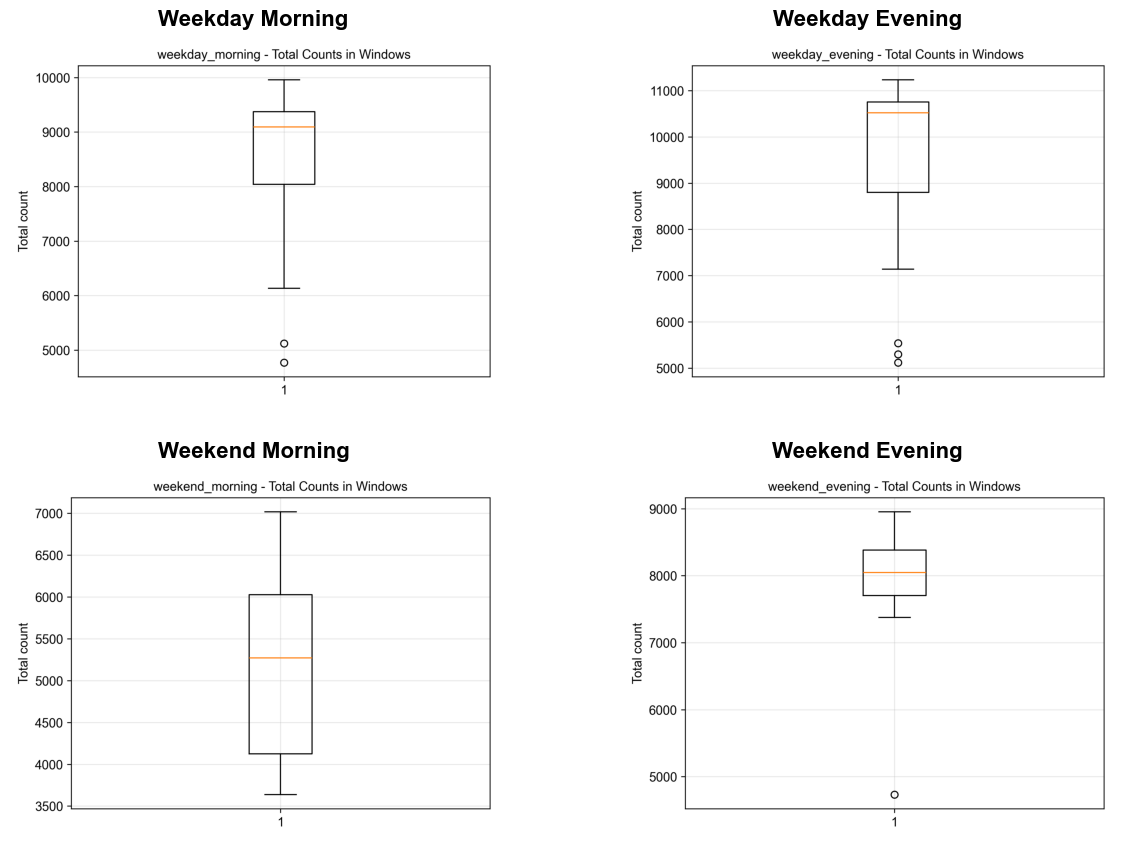

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\detector_data_CSV_new\kmeans_representative_days\combined_boxplot_total_counts.png


In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ============================================================
# THESIS STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# ============================================================
# SETTINGS
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\detector_data_CSV_new\kmeans_representative_days"
)

scenarios = [
    ("weekday_morning", "Weekday Morning"),
    ("weekday_evening", "Weekday Evening"),
    ("weekend_morning", "Weekend Morning"),
    ("weekend_evening", "Weekend Evening"),
]

suffix = "boxplot_total_counts.png"

out_file = BASE_DIR / "combined_boxplot_total_counts.png"

# ============================================================
# CREATE COMBINED FIGURE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (scenario, title) in zip(axes, scenarios):

    img_path = BASE_DIR / f"{scenario}_{suffix}"

    if not img_path.exists():
        raise FileNotFoundError(f"File not found: {img_path}")

    img = mpimg.imread(img_path)

    ax.imshow(img)
    ax.set_title(title, fontsize=16, fontweight="bold", pad=12)
    ax.axis("off")

plt.tight_layout(pad=2.0)

plt.savefig(out_file, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved: {out_file}")

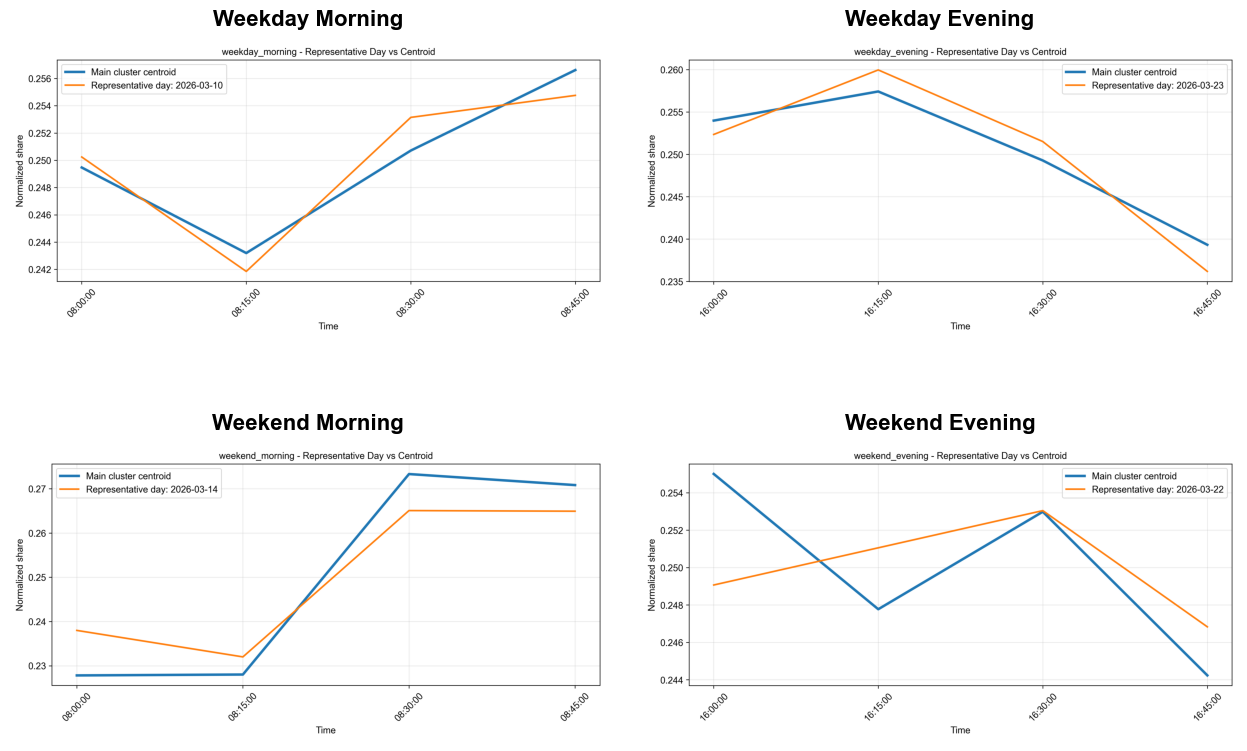

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\detector_data_CSV_new\kmeans_representative_days\combined_representative_vs_centroid.png


In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ============================================================
# THESIS STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# ============================================================
# SETTINGS
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\detector_data_CSV_new\kmeans_representative_days"
)

scenarios = [
    ("weekday_morning", "Weekday Morning"),
    ("weekday_evening", "Weekday Evening"),
    ("weekend_morning", "Weekend Morning"),
    ("weekend_evening", "Weekend Evening"),
]

suffix = "representative_vs_centroid.png"

out_file = BASE_DIR / "combined_representative_vs_centroid.png"

# ============================================================
# CREATE COMBINED FIGURE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (scenario, title) in zip(axes, scenarios):

    img_path = BASE_DIR / f"{scenario}_{suffix}"

    if not img_path.exists():
        raise FileNotFoundError(f"File not found: {img_path}")

    img = mpimg.imread(img_path)

    ax.imshow(img)
    ax.set_title(title, fontsize=16, fontweight="bold", pad=12)
    ax.axis("off")

plt.tight_layout(pad=2.0)

plt.savefig(out_file, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved: {out_file}")